# 6CS012 – Part III: Natural Language Processing Task
## Hate Speech Detection: Binary Tweet Classification using RNN, LSTM & Word2Vec

**Dataset:** Racist / Sexist Tweets  
**Objective:** Binary Text Classification — Label `1` = Hate Speech &nbsp;|&nbsp; Label `0` = Neutral  


## Section 1: Environment Setup


### 1.1 Dependency Installation


In [58]:
# One-time install of all required packages for this notebook
!pip install numpy==1.23.5 gensim nltk wordcloud gradio -q

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


### 1.2 Module Imports


In [59]:
# Built-in modules
import re
import time
import warnings
warnings.filterwarnings('ignore')

# Numerical and tabular data
import numpy as np
import pandas as pd

# Plotting and visual analytics
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Natural language processing toolkit
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Keras / TensorFlow components
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Pre-trained vector loading via Gensim
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gensim', '-q'])
import gensim.downloader as gensim_api

print(f"TensorFlow: {tf.__version__} | NumPy: {np.__version__}")

TensorFlow: 2.20.0 | NumPy: 2.0.2


### 1.3 Drive Mount (Colab)


In [60]:
# Connect Google Drive to access the dataset files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Section 2: Data Ingestion


### 2.1 Dataset File Paths


In [61]:
train_dir = '/content/drive/MyDrive/Dataset/train_racisit.csv'
test_dir  = '/content/drive/MyDrive/Dataset/test_racisit.csv'

### 2.2 Read CSV Files into DataFrames


In [62]:
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

### 2.3 Initial Data Preview


In [63]:
print(f"Train shape: {train_df.shape} | Test shape: {test_df.shape}")
train_df.head()

Train shape: (31962, 3) | Test shape: (17197, 2)


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [64]:
test_df.head()

,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedic...
1,31964,@user #white #supremacists want everyone to s...
2,31965,safe ways to heal your #acne!! #altwaystohe...
3,31966,is the hp and the cursed child book up for res...
4,31967,"3rd #bihday to my amazing, hilarious #nephew..."


## Section 3: Exploratory Analysis


### 3.1 Schema & Null Check


In [65]:
# Inspect column types and count any null entries
train_df.info()
print("\nMissing values:\n", train_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB

Missing values:
 id       0
label    0
tweet    0
dtype: int64


### 3.2 Label Balance


In [66]:
# Count label occurrences and compute class proportions
labels = train_df['label'].value_counts()
print(f"Class 0 (Not Hate): {labels[0]} ({labels[0]/len(train_df)*100:.1f}%)")
print(f"Class 1 (Hate)    : {labels[1]} ({labels[1]/len(train_df)*100:.1f}%)")

Class 0 (Not Hate): 29720 (93.0%)
Class 1 (Hate)    : 2242 (7.0%)


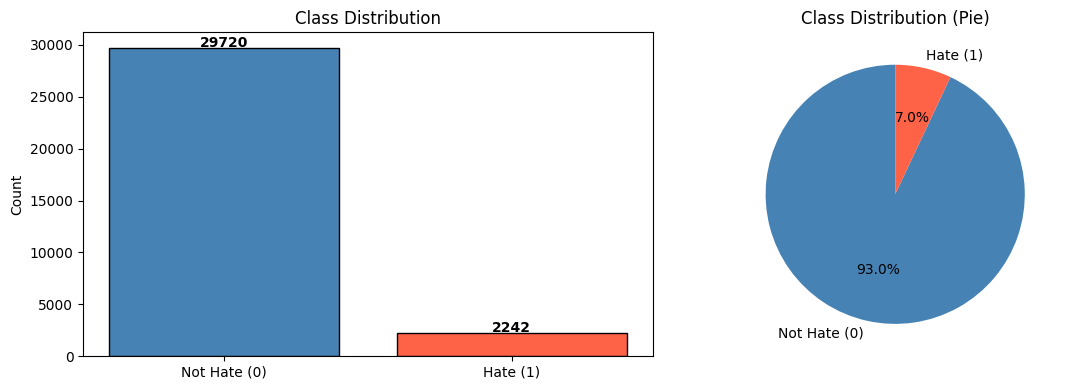

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Not Hate (0)', 'Hate (1)'], labels.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(labels.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(labels.values, labels=['Not Hate (0)', 'Hate (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Distribution (Pie)')
plt.tight_layout()
plt.show()

### 3.3 Token Count Distribution


In [68]:
# Compute word count per tweet and summarise by class
train_df['tweet_length'] = train_df['tweet'].apply(lambda x: len(str(x).split()))
print(train_df['tweet_length'].describe())

count    31962.00000
mean        13.15872
std          5.47815
min          3.00000
25%          9.00000
50%         13.00000
75%         17.00000
max         34.00000
Name: tweet_length, dtype: float64


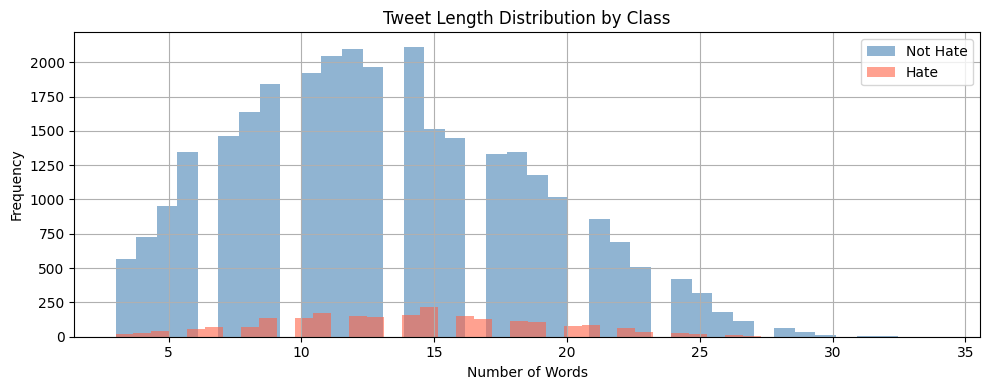

In [69]:
fig, ax = plt.subplots(figsize=(10, 4))
train_df[train_df['label'] == 0]['tweet_length'].hist(bins=40, alpha=0.6, color='steelblue', label='Not Hate', ax=ax)
train_df[train_df['label'] == 1]['tweet_length'].hist(bins=40, alpha=0.6, color='tomato', label='Hate', ax=ax)
ax.set_title('Tweet Length Distribution by Class')
ax.set_xlabel('Number of Words')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

### 3.4 Raw Tweet Samples


In [70]:
# Print a few raw examples from both label categories
print("Non-Hate samples:")
for t in train_df[train_df['label'] == 0]['tweet'].head(3).values:
    print(" •", t)

print("\nHate samples:")
for t in train_df[train_df['label'] == 1]['tweet'].head(3).values:
    print(" •", t)

Non-Hate samples:
 •  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
 • @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
 •   bihday your majesty

Hate samples:
 • @user #cnn calls #michigan middle school 'build the wall' chant '' #tcot  
 • no comment!  in #australia   #opkillingbay #seashepherd #helpcovedolphins #thecove  #helpcovedolphins
 • retweet if you agree! 


## Section 4: Text Cleaning


### 4.1 Cleaning Configuration


In [71]:
# Lookup table for expanding common English contractions
CONTRACTIONS = {
    "don't": "do not", "can't": "cannot", "won't": "will not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "haven't": "have not", "hasn't": "has not",
    "hadn't": "had not", "didn't": "did not", "doesn't": "does not",
    "wouldn't": "would not", "couldn't": "could not", "shouldn't": "should not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "it's": "it is", "that's": "that is", "what's": "what is",
    "he's": "he is", "she's": "she is", "they're": "they are",
    "you're": "you are", "we're": "we are", "you've": "you have",
    "they've": "they have", "you'll": "you will", "they'll": "they will",
    "let's": "let us", "there's": "there is",
}

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

### 4.2 Contraction Resolver


In [72]:
def expand_contractions(text):
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    return text

### 4.3 Text Normalisation Pipeline


In [73]:
# Sequential cleaning: lowercase, strip URLs/mentions/hashtags, expand contractions, remove non-alpha, filter stopwords, lemmatize
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@[\w]+', '', text)
    text = re.sub(r'#', '', text)
    text = expand_contractions(text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

### 4.4 Run Cleaning


In [74]:
# Run the normalisation pipeline over every tweet in both splits
train_df['clean_tweet'] = train_df['tweet'].apply(clean_tweet)
test_df['clean_tweet']  = test_df['tweet'].apply(clean_tweet)

### 4.5 Before / After Comparison


In [75]:
print("Before → After (3 examples):")
for i in range(3):
    print(f"\n  ORIGINAL : {train_df['tweet'].iloc[i]}")
    print(f"  CLEANED  : {train_df['clean_tweet'].iloc[i]}")

Before → After (3 examples):

  ORIGINAL :  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
  CLEANED  : father dysfunctional selfish drag kid dysfunction run

  ORIGINAL : @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
  CLEANED  : thanks lyft credit use cause offer wheelchair van pdx disapointed getthanked

  ORIGINAL :   bihday your majesty
  CLEANED  : bihday majesty


### 4.6 Term Frequency Word Clouds


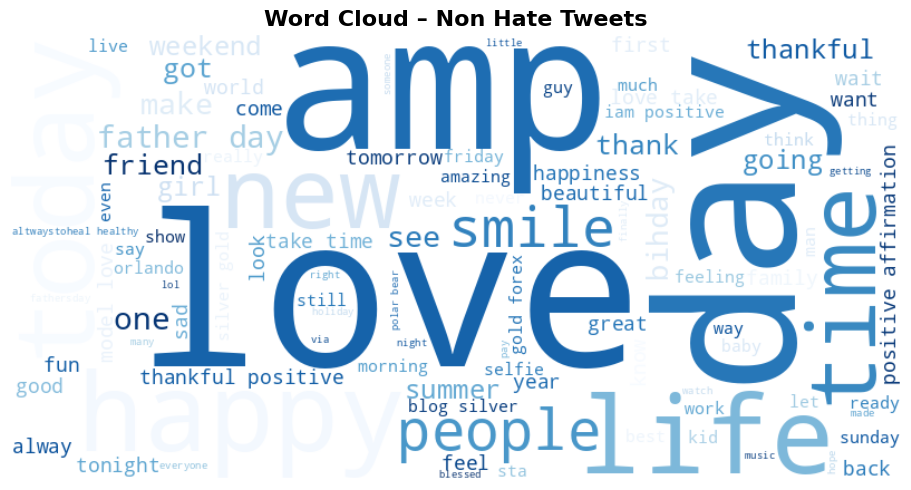

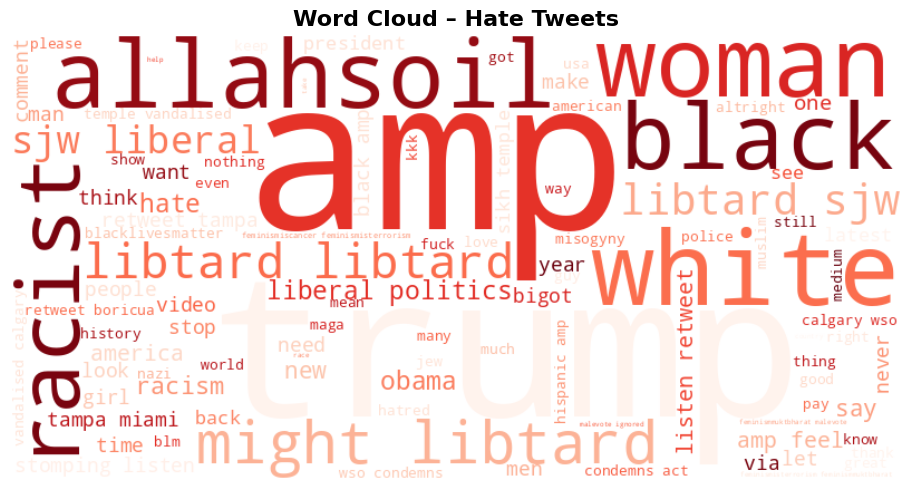

In [76]:
# Generate term-frequency word clouds for each label category
def make_wordcloud(texts, title, colormap='Blues'):
    corpus = ' '.join(texts)
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=colormap, max_words=100).generate(corpus)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

make_wordcloud(train_df[train_df['label'] == 0]['clean_tweet'].values, 'Word Cloud – Non Hate Tweets', 'Blues')
make_wordcloud(train_df[train_df['label'] == 1]['clean_tweet'].values, 'Word Cloud – Hate Tweets', 'Reds')

## Section 5: Sequence Encoding


### 5.1 Global Settings


In [77]:
# Shared hyperparameters used across all three models
vocab_size    = 10_000
OOV_token     = '<OOV>'
embedding_dim = 50
batch_size    = 64
EPOCHS        = 20

### 5.2 Stratified Train / Validation Split


In [78]:
# Separate features and labels before splitting
X = train_df['clean_tweet'].values
y = train_df['label'].values

In [79]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)} | Val: {len(X_val)}")

Train: 25569 | Val: 6393


### 5.3 Vocabulary Fitting


In [80]:
# Build word-to-index vocabulary from training corpus only
tokenizer = Tokenizer(num_words=vocab_size, oov_token=OOV_token)
tokenizer.fit_on_texts(X_train)
print(f"Full vocab: {len(tokenizer.word_index)} | Capped at: {vocab_size}")

Full vocab: 31856 | Capped at: 10000


### 5.4 Max Sequence Length Selection


In [81]:
# 95th-percentile length keeps most tweets whole while limiting padding waste
max_length = int(np.percentile([len(s.split()) for s in X_train], 95))
print(f"MAX_LENGTH (95th percentile): {max_length}")

MAX_LENGTH (95th percentile): 12


### 5.5 Integer Encoding & Padding


In [82]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(test_df['clean_tweet'].values)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_length, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_length, padding='post', truncating='post')

print(f"X_train_pad: {X_train_pad.shape} | X_val_pad: {X_val_pad.shape}")

X_train_pad: (25569, 12) | X_val_pad: (6393, 12)


### 5.6 Shared Utility Functions


In [83]:
# Utility: render side-by-side accuracy and loss learning curves
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, metric in zip(axes, ['accuracy', 'loss']):
        ax.plot(history.history[metric], label=f'Train {metric.capitalize()}')
        ax.plot(history.history[f'val_{metric}'], label=f'Val {metric.capitalize()}')
        ax.set_title(f'{model_name} – {metric.capitalize()}')
        ax.set_xlabel('Epoch')
        ax.legend()
    plt.tight_layout()
    plt.show()

In [84]:
# Utility: threshold predictions, report per-class metrics, and display confusion matrix
def evaluate_model(model, X_val_pad, y_val, model_name):
    y_pred = (model.predict(X_val_pad, verbose=0) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_val, y_pred)
    print(f"\n{model_name} | Accuracy: {acc*100:.2f}%")
    print(classification_report(y_val, y_pred, target_names=['Not Hate', 'Hate']))
    ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred),
                           display_labels=['Not Hate', 'Hate']).plot(cmap='Blues')
    plt.title(f'{model_name} – Confusion Matrix')
    plt.tight_layout()
    plt.show()
    return acc, y_pred


In [85]:
# Utility: returns early-stopping and best-checkpoint callbacks for any model
def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'{name}_best.h5', monitor='val_accuracy', save_best_only=True, verbose=0)
    ]

## Section 6: Baseline — Simple RNN


### 6.1 Network Architecture


In [86]:
# Simple RNN baseline: learned embeddings feed into a single recurrent layer
model1 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(max_length,)),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='Model1_SimpleRNN')

model1.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])

### 6.2 Architecture Summary


In [87]:
model1.summary()

Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 12, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         7,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 509,473 (1.94 MB)

 Trainable params: 509,473 (1.94 MB)

 Non-trainable params: 0 (0.00 B)

### 6.3 Training & Results


Epoch 1/20
397/400 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9270 - loss: 0.2574

400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9462 - loss: 0.1890 - val_accuracy: 0.9590 - val_loss: 0.1399
Epoch 2/20
398/400 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9760 - loss: 0.0833

400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9752 - loss: 0.0812 - val_accuracy: 0.9592 - val_loss: 0.1404
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9881 - loss: 0.0403 - val_accuracy: 0.9562 - val_loss: 0.1859
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9935 - loss: 0.0229 - val_accuracy: 0.9550 - val_loss: 0.1697
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9961 - loss: 0.0156 - val_accuracy: 0.9548 - val_loss: 0.2021
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Training time: 0.5 min


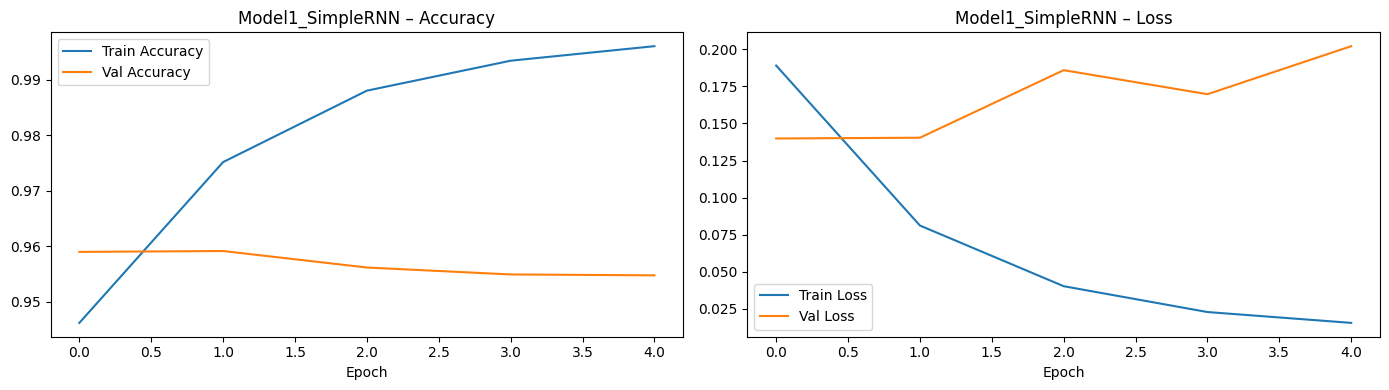


Model1_SimpleRNN | Accuracy: 95.90%
              precision    recall  f1-score   support

    Not Hate       0.96      0.99      0.98      5945
        Hate       0.85      0.50      0.63       448

    accuracy                           0.96      6393
   macro avg       0.91      0.75      0.81      6393
weighted avg       0.96      0.96      0.95      6393



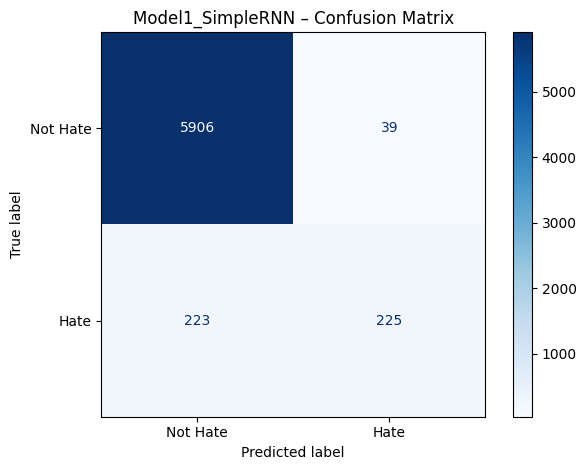

In [88]:
# Fit the Simple RNN and record training time
t0 = time.time()
history1 = model1.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
                      epochs=EPOCHS, batch_size=batch_size,
                      callbacks=get_callbacks('model1'), verbose=1)
print(f"Training time: {(time.time()-t0)/60:.1f} min")

plot_history(history1, 'Model1_SimpleRNN')
acc1, pred1 = evaluate_model(model1, X_val_pad, y_val, 'Model1_SimpleRNN')

## Section 7: LSTM with Learned Embeddings


### 7.1 Network Architecture


In [89]:
# LSTM variant: replaces the vanilla RNN cell with gated LSTM units
model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(max_length,)),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='Model2_LSTM')

model2.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])


### 7.2 Architecture Summary


In [90]:
model2.summary()

Model: "Model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 12, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,553 (2.03 MB)

 Trainable params: 531,553 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

### 7.3 Training


In [91]:
# Fit the LSTM model and record training time
t0 = time.time()
history2 = model2.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
                      epochs=EPOCHS, batch_size=batch_size,
                      callbacks=get_callbacks('model2'), verbose=1)
print(f"Training time: {(time.time()-t0)/60:.1f} min")

Epoch 1/20
398/400 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9298 - loss: 0.2824

400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9454 - loss: 0.1891 - val_accuracy: 0.9584 - val_loss: 0.1294
Epoch 2/20
399/400 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9737 - loss: 0.0809

400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9732 - loss: 0.0821 - val_accuracy: 0.9618 - val_loss: 0.1157
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9820 - loss: 0.0548 - val_accuracy: 0.9618 - val_loss: 0.1495
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9867 - loss: 0.0424 - val_accuracy: 0.9607 - val_loss: 0.1545
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.9903 - loss: 0.0320 - val_accuracy: 0.9584 - val_loss: 0.1574
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9920 - loss: 0.0245 - val_accuracy: 0.9578 - val_loss: 0.2068
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
Training time: 1.0 min


### 7.4 Results


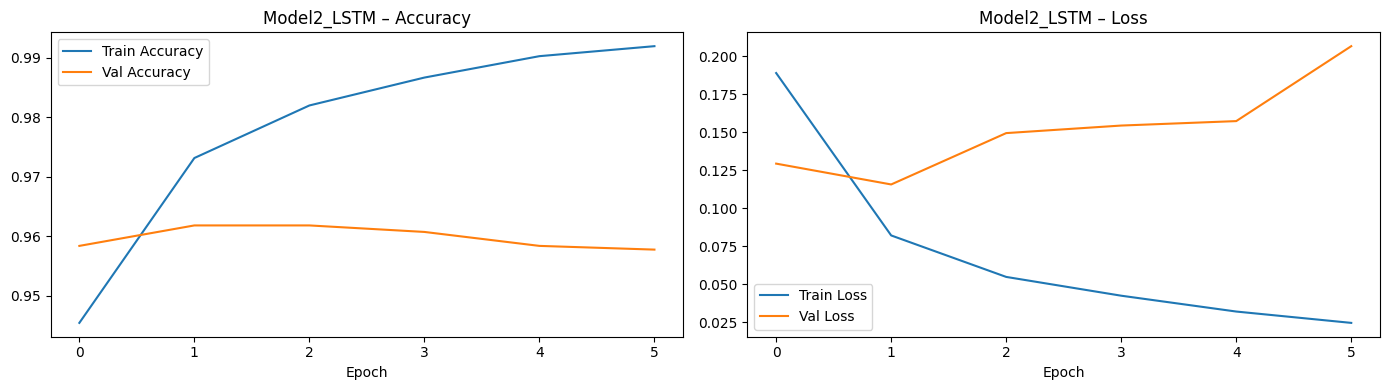


Model2_LSTM | Accuracy: 96.18%
              precision    recall  f1-score   support

    Not Hate       0.97      0.99      0.98      5945
        Hate       0.84      0.56      0.67       448

    accuracy                           0.96      6393
   macro avg       0.90      0.78      0.83      6393
weighted avg       0.96      0.96      0.96      6393



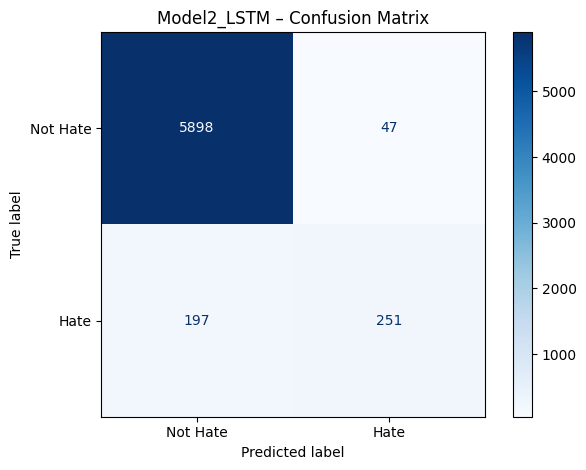

In [92]:
plot_history(history2, 'Model2_LSTM')
acc2, pred2 = evaluate_model(model2, X_val_pad, y_val, 'Model2_LSTM')

## Section 8: LSTM with Pre-trained Word2Vec


### 8.1 Load Word2Vec Vectors


In [93]:
# Fetch Google News Word2Vec (300-dim, ~1.6 GB) — run once and cache locally
w2v_model = gensim_api.load('word2vec-google-news-300')
embedding_dim_w2v = 300   # must match the loaded model's vector size
print("Word2Vec loaded.")

Word2Vec loaded.


### 8.2 Construct Embedding Matrix


In [94]:
# Populate the embedding matrix with Word2Vec vectors for known vocabulary words
embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))
found = 0

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in w2v_model:
        embedding_matrix[idx] = w2v_model[word]
        found += 1

In [95]:
print(f"Words mapped to Word2Vec: {found} | Coverage: {found/min(vocab_size, len(tokenizer.word_index))*100:.1f}%")

Words mapped to Word2Vec: 7601 | Coverage: 76.0%


### 8.3 Network Architecture


In [96]:
# LSTM + Word2Vec: pre-trained vectors are frozen so only downstream layers learn
model3 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim_w2v,
              weights=[embedding_matrix], input_shape=(max_length,) ,trainable=False),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='Model3_LSTM_Word2Vec')

model3.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
model3.summary()

Model: "Model3_LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 12, 300)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,095,553 (11.81 MB)

 Trainable params: 95,553 (373.25 KB)

 Non-trainable params: 3,000,000 (11.44 MB)

In [97]:
model3.summary()

Model: "Model3_LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 12, 300)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,095,553 (11.81 MB)

 Trainable params: 95,553 (373.25 KB)

 Non-trainable params: 3,000,000 (11.44 MB)

### 8.4 Training


In [98]:
# Fit the Word2Vec-backed LSTM and record training time
t0 = time.time()
history3 = model3.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
                      epochs=EPOCHS, batch_size=batch_size,
                      callbacks=get_callbacks('model3'), verbose=1)
print(f"Training time: {(time.time()-t0)/60:.1f} min")

Epoch 1/20
398/400 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9159 - loss: 0.2822

400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.9370 - loss: 0.2008 - val_accuracy: 0.9478 - val_loss: 0.1458
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9510 - loss: 0.1472

400/400 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.9511 - loss: 0.1455 - val_accuracy: 0.9504 - val_loss: 0.1396
Epoch 3/20
398/400 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9556 - loss: 0.1262

400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9546 - loss: 0.1334 - val_accuracy: 0.9517 - val_loss: 0.1370
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9579 - loss: 0.1213

400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9576 - loss: 0.1235 - val_accuracy: 0.9545 - val_loss: 0.1309
Epoch 5/20
399/400 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9591 - loss: 0.1140

...

400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9680 - loss: 0.0943 - val_accuracy: 0.9568 - val_loss: 0.1371
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9712 - loss: 0.0845

400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9715 - loss: 0.0856 - val_accuracy: 0.9573 - val_loss: 0.1296
Epoch 9/20
397/400 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9738 - loss: 0.0761

400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9743 - loss: 0.0769 - val_accuracy: 0.9596 - val_loss: 0.1376
Epoch 10/20
399/400 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9783 - loss: 0.0658

400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9771 - loss: 0.0672 - val_accuracy: 0.9606 - val_loss: 0.1340
Epoch 11/20
399/400 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9795 - loss: 0.0568

400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9782 - loss: 0.0616 - val_accuracy: 0.9628 - val_loss: 0.1379
Epoch 12/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9823 - loss: 0.0517 - val_accuracy: 0.9504 - val_loss: 0.1688
Epoch 12: early stopping
Restoring model weights from the end of the best epoch: 8.
Training time: 2.0 min


### 8.5 Results


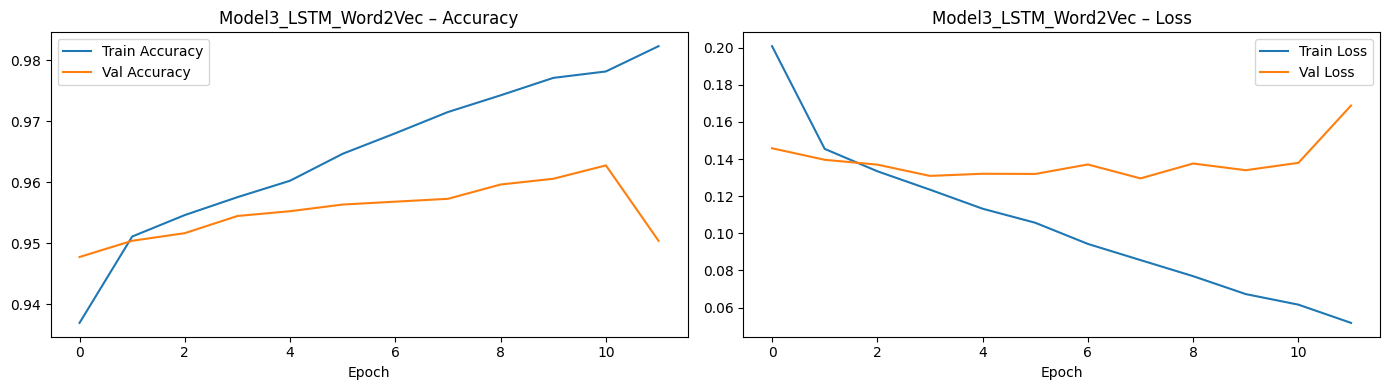


Model3_LSTM_Word2Vec | Accuracy: 95.73%
              precision    recall  f1-score   support

    Not Hate       0.97      0.99      0.98      5945
        Hate       0.76      0.57      0.65       448

    accuracy                           0.96      6393
   macro avg       0.87      0.78      0.81      6393
weighted avg       0.95      0.96      0.95      6393



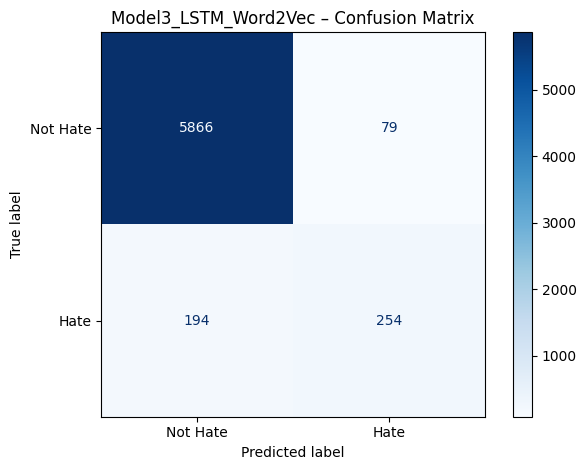

In [99]:
plot_history(history3, 'Model3_LSTM_Word2Vec')
acc3, pred3 = evaluate_model(model3, X_val_pad, y_val, 'Model3_LSTM_Word2Vec')

## Section 9: Cross-Model Comparison


### 9.1 Validation Accuracy Bar Chart


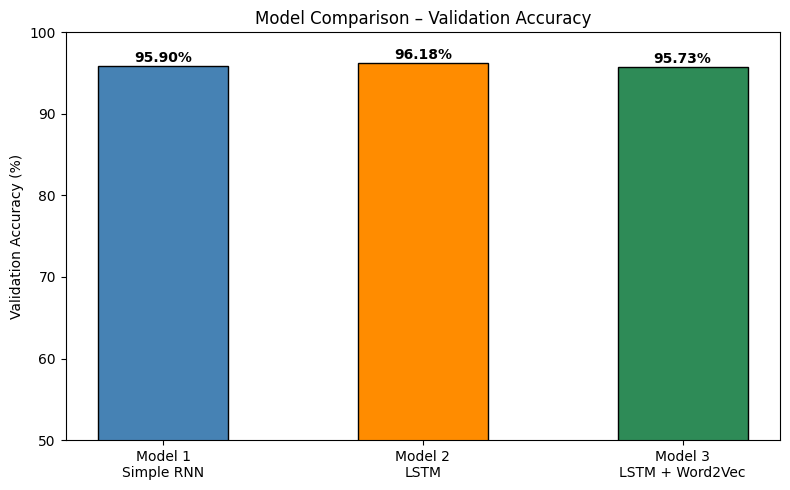

In [100]:
# Side-by-side bar chart of validation accuracy for quick model comparison
model_names = ['Model 1\nSimple RNN', 'Model 2\nLSTM', 'Model 3\nLSTM + Word2Vec']
accuracies  = [acc1 * 100, acc2 * 100, acc3 * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies,
               color=['steelblue', 'darkorange', 'seagreen'], edgecolor='black', width=0.5)
plt.ylim(50, 100)
plt.ylabel('Validation Accuracy (%)')
plt.title('Model Comparison – Validation Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 9.2 Validation Loss Curves


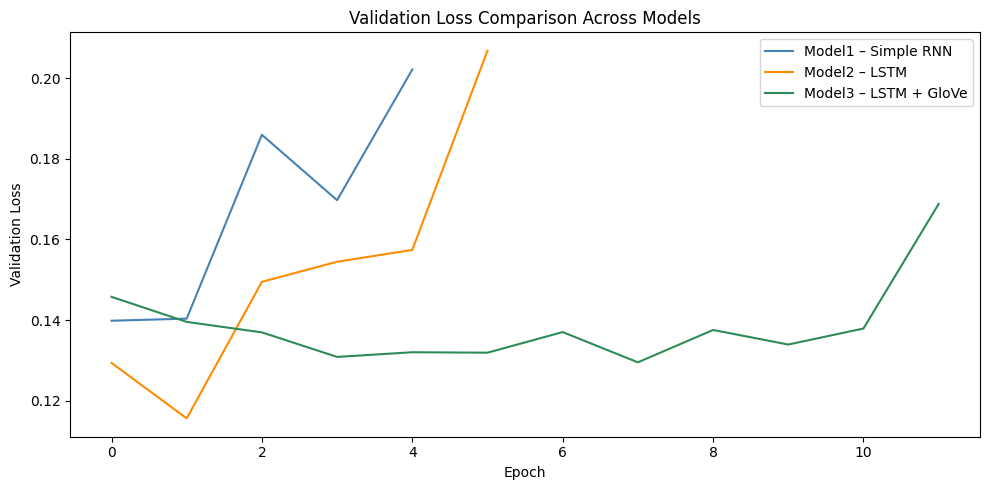

In [101]:
# Overlay validation loss curves to compare how quickly each model converges
plt.figure(figsize=(10, 5))
plt.plot(history1.history['val_loss'], label='Model1 – Simple RNN',  color='steelblue')
plt.plot(history2.history['val_loss'], label='Model2 – LSTM',         color='darkorange')
plt.plot(history3.history['val_loss'], label='Model3 – LSTM + GloVe', color='seagreen')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Comparison Across Models')
plt.legend()
plt.tight_layout()
plt.show()

### 9.3 Results Summary Table


In [102]:
# Consolidated results table: architecture, embedding type, and validation accuracy
summary = pd.DataFrame({
    'Model'        : ['Model1_SimpleRNN', 'Model2_LSTM', 'Model3_LSTM_GloVe'],
    'Embedding'    : ['Trainable', 'Trainable', 'Pre-trained GloVe (frozen)'],
    'Val_Accuracy' : [f'{acc1*100:.2f}%', f'{acc2*100:.2f}%', f'{acc3*100:.2f}%'],
})
print(summary.to_string(index=False))

            Model                  Embedding Val_Accuracy
 Model1_SimpleRNN                  Trainable       95.90%
      Model2_LSTM                  Trainable       96.18%
Model3_LSTM_GloVe Pre-trained GloVe (frozen)       95.73%


## Section 10: Error Investigation


### 10.1 Locate Misclassified Examples


In [103]:
# Reconstruct the validation subset so predictions can be matched to source tweets
_, val_idx = train_test_split(np.arange(len(train_df)), test_size=0.2,
                              random_state=42, stratify=train_df['label'].values)

val_df = train_df.iloc[val_idx].copy().reset_index(drop=True)
val_df['predicted'] = pred3
val_df['correct']   = (val_df['label'] == val_df['predicted'])

mistakes = val_df[~val_df['correct']].reset_index(drop=True)
print(f"Misclassified: {len(mistakes)} / {len(val_df)} ({len(mistakes)/len(val_df)*100:.1f}%)")

Misclassified: 273 / 6393 (4.3%)


### 10.2 Review Individual Mistakes


In [104]:
# Print up to 3 misclassified tweets with their true and predicted labels
for i in range(min(3, len(mistakes))):
    row = mistakes.iloc[i]
    print(f"\nExample {i+1}")
    print(f"  Tweet     : {row['tweet']}")
    print(f"  True Label: {int(row['label'])} ({'Hate' if row['label']==1 else 'Not Hate'})")
    print(f"  Predicted : {int(row['predicted'])} ({'Hate' if row['predicted']==1 else 'Not Hate'})")


Example 1
  Tweet     : the immature @user is just trying to make a fool of @user   #xenophobe #immature #moron 
  True Label: 1 (Hate)
  Predicted : 0 (Not Hate)

Example 2
  Tweet     :  porn vids web free sex 
  True Label: 1 (Hate)
  Predicted : 0 (Not Hate)

Example 3
  Tweet     : "yapping" is right...  # idiot #trump
  True Label: 0 (Not Hate)
  Predicted : 1 (Hate)


### 10.3 False Positive & False Negative Counts


In [105]:
# Quantify false alarms (FP) and missed detections (FN) separately
fp = len(val_df[(val_df['label']==0) & (val_df['predicted']==1)])
fn = len(val_df[(val_df['label']==1) & (val_df['predicted']==0)])
print(f"False Positives (predicted Hate, actually Not Hate): {fp}")
print(f"False Negatives (predicted Not Hate, actually Hate): {fn}")

False Positives (predicted Hate, actually Not Hate): 79
False Negatives (predicted Not Hate, actually Hate): 194


### 10.4 Root Cause Analysis


In [106]:
print("\nLikely contributing factors:")
print("  1. Sarcasm or irony making the true intent unclear")
print("  2. Very short tweets that lose meaning after stopword removal")
print("  3. Out-of-vocabulary slang not present in the Word2Vec corpus")
print("  4. Severe label skew (~93% non-hate) pushes the model toward the majority class")


Likely contributing factors:
  1. Sarcasm or irony making the true intent unclear
  2. Very short tweets that lose meaning after stopword removal
  3. Out-of-vocabulary slang not present in the Word2Vec corpus
  4. Severe label skew (~93% non-hate) pushes the model toward the majority class


### 10.5 Recommendations for Future Work


In [107]:
print("\nPotential next steps:")
print("  • Apply class-weighted loss to up-weight minority-class errors")
print("  • Replace unidirectional LSTM with a Bidirectional wrapper")
print("  • Experiment with domain-adapted embeddings (e.g. glove-twitter-100)")
print("  • Unfreeze and fine-tune the embedding layer on social-media corpora")


Potential next steps:
  • Apply class-weighted loss to up-weight minority-class errors
  • Replace unidirectional LSTM with a Bidirectional wrapper
  • Experiment with domain-adapted embeddings (e.g. glove-twitter-100)
  • Unfreeze and fine-tune the embedding layer on social-media corpora
